# Feature Engineering

## Approach

Raw sensor readings encode the operating state of the machine but not its physics. Feature engineering here augments the raw signals with derived quantities grounded in mechanical engineering. Each engineered feature has a real-world justification that does *not* depend on knowing how this dataset was generated.

**Three principles guide the choices:**

1. **Real-world ME grounding.** Each engineered feature should correspond to a quantity a chartered mechanical engineer would compute when diagnosing milling-machine performance. Features inferred from the AI4I dataset's documented generating process (e.g. specific OSF threshold formulas) are explicitly excluded — those would not be available in real deployment.

2. **Avoid redundancy for tree models.** Tree-based models like LightGBM learn interaction effects natively through their split structure. Pre-computed interaction features (e.g. products of two existing features) add multicollinearity without new information, weakening SHAP attribution. We only engineer features that encode *non-linear transformations* trees cannot easily learn — such as ratios across rows or threshold flags.

3. **Honest documentation of placeholders.** Where a feature requires a numeric calibration that would come from manufacturer or deployment context (e.g. tool change-out interval), we use a placeholder value and document that the deployment-specific value would need to be supplied at integration time.

## Feature set summary

| Feature | Type | Source | ME justification |
|---|---|---|---|
| Air_Temp | Raw | Sensor | Ambient temperature, baseline for heat transfer |
| Process_Temp | Raw | Sensor | Spindle/cutting zone temperature |
| Rotational_Speed | Raw | Sensor | Spindle RPM |
| Torque | Raw | Sensor | Cutting torque |
| Tool_Wear | Raw | Sensor | Accumulated tool use in minutes |
| Type_L, Type_M, Type_H | Categorical (one-hot) | Sensor | Product quality grade |
| Temp_Delta | Engineered | Process_Temp − Air_Temp | Temperature gradient driving heat transfer |
| Power_W | Engineered | Torque × ω | Actual mechanical power dissipation |
| Energy_Per_Wear | Engineered | Power_W / (Tool_Wear + 1) | Specific cutting energy proxy — rises as tool dulls |
| Tool_Wear_Risk_Zone | Engineered (boolean) | Tool_Wear > T_threshold | Manufacturer-specified end-of-life flag |

Total: 12 features (5 raw + 3 categorical + 3 engineered continuous + 1 engineered boolean).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/processed/ai4i2020_processed.csv')
print(f'Loaded {len(df)} rows from cleaned data.')
print(f'Columns: {list(df.columns)}')
df.head()

Loaded 10000 rows from cleaned data.
Columns: ['ID', 'Product_ID', 'Product_Type', 'Air_Temp', 'Process_Temp', 'Rotational_Speed', 'Torque', 'Tool_Wear', 'Machine_Failure', 'Tool_Wear_Failure', 'Heat_Dissipation_Failure', 'Power_Failure', 'Overstrain_Failure', 'Random_Failure']


,ID,Product_ID,Product_Type,Air_Temp,Process_Temp,Rotational_Speed,Torque,Tool_Wear,Machine_Failure,Tool_Wear_Failure,Heat_Dissipation_Failure,Power_Failure,Overstrain_Failure,Random_Failure
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 1. Temp_Delta — Temperature Gradient

**Definition:** `Temp_Delta = Process_Temp − Air_Temp` (both in Kelvin).

**ME justification:** the rate of heat transfer from the cutting zone to the surroundings is driven by the temperature gradient between them (Fourier's law of conduction; Newton's law of cooling). A larger gradient means heat is being removed efficiently. A *narrowing* gradient over time, holding cutting parameters constant, means the cooling system is losing capacity — coolant flow restricted, heat exchanger fouled, ambient airflow blocked, etc.

**Why this isn't redundant with raw temperatures:** the raw sensors give absolute temperatures, but heat transfer depends on the *difference*. A tree model can in principle subtract these features at a split node, but the subtraction would have to happen across two consecutive splits which is harder for the model to discover than presenting the difference directly. This is an example of where pre-computing the feature provides a small but real benefit.

In [2]:
df['Temp_Delta'] = df['Process_Temp'] - df['Air_Temp']

print('Temp_Delta statistics:')
print(df['Temp_Delta'].describe())
print()
print('Temp_Delta by failure outcome:')
print(df.groupby('Machine_Failure')['Temp_Delta'].describe()[['mean', 'std', 'min', 'max']])

Temp_Delta statistics:
count    10000.000000
mean        10.000630
std          1.001094
min          7.600000
25%          9.300000
50%          9.800000
75%         11.000000
max         12.100000
Name: Temp_Delta, dtype: float64

Temp_Delta by failure outcome:
                      mean       std  min   max
Machine_Failure                                
0                10.021571  0.988422  7.6  12.1
1                 9.403835  1.164445  7.6  12.0


## 2. Power_W — Mechanical Power Output

**Definition:** `Power_W = Torque × ω = Torque × Rotational_Speed × (2π / 60) ≈ Torque × RPM × 0.1047`

**ME justification:** for a rotating shaft, instantaneous mechanical power is the product of torque and angular velocity. The factor 0.1047 = 2π/60 converts revolutions per minute to radians per second. This gives power in watts directly.

**Why engineer this rather than letting the tree learn it:** the *product* of torque and speed is the physically meaningful quantity. Two operating points with the same torque and the same speed produce the same mechanical power and the same heat generation. A tree model presented with separate torque and speed features can approximate the interaction across multiple splits, but the approximation is grid-aligned rather than smooth. Pre-computing the product gives the model the physical quantity directly.

**Independent of Risk_Heuristic.** The previous version of this notebook also created `Risk_Heuristic = Power_W × Temp_Delta`. We are *not* doing that here. For tree models, a product of two features that are themselves in the feature set adds multicollinearity without new information — and weakens SHAP attribution because the same physical effect gets split across three correlated features. Power_W stays; Risk_Heuristic does not.

In [3]:
RPM_TO_RAD_PER_SEC = 2 * np.pi / 60  # ≈ 0.10472
df['Power_W'] = df['Torque'] * df['Rotational_Speed'] * RPM_TO_RAD_PER_SEC

print('Power_W statistics (Watts):')
print(df['Power_W'].describe())
print()
print('Power_W by failure outcome:')
print(df.groupby('Machine_Failure')['Power_W'].describe()[['mean', 'std', 'min', 'max']])

Power_W statistics (Watts):
count    10000.000000
mean      6279.744953
std       1067.418295
min       1148.440610
25%       5561.184484
50%       6271.027344
75%       7003.002724
max      10469.923005
Name: Power_W, dtype: float64

Power_W by failure outcome:
                        mean          std          min           max
Machine_Failure                                                     
0                6244.547534  1011.394393  3515.033772   8998.024015
1                7282.819485  1851.137977  1148.440610  10469.923005


## 3. Energy_Per_Wear — Specific Cutting Energy Proxy

**Definition:** `Energy_Per_Wear = Power_W / (Tool_Wear + 1)` (the +1 avoids division by zero for fresh tools).

**ME justification:** specific cutting energy (SCE) is the energy required per unit of work done, and is a standard metric in machining for tracking tool condition. It's classically defined as:

$$ SCE = \frac{\text{Cutting force} \times \text{Cutting speed}}{\text{Material removal rate}} $$

Material removal rate isn't directly available here (we'd need feed rate and depth of cut). But cumulative tool wear is itself a function of total work done — a tool with high accumulated wear has performed more work. So `Power / Tool_Wear` approximates 'energy expended per unit of accumulated work', which is dimensionally analogous to specific cutting energy.

**What this captures physically:** as a tool dulls, it needs *more force and more energy* to remove the same volume of material. A rising `Energy_Per_Wear` over time means the tool is becoming less efficient — the classic dulling signature. A tool that's failing through chipping or built-up edge will also show elevated SCE because the cutting geometry is degraded.

**This is non-redundant** because it's a ratio of two features, not a product. Trees cannot easily approximate ratios at split nodes (a ratio crossing a threshold corresponds to a non-axis-aligned boundary in feature space, which trees only approximate through deep nested splits).

In [4]:
df['Energy_Per_Wear'] = df['Power_W'] / (df['Tool_Wear'] + 1)

print('Energy_Per_Wear statistics:')
print(df['Energy_Per_Wear'].describe())
print()
print('Energy_Per_Wear by failure outcome:')
print(df.groupby('Machine_Failure')['Energy_Per_Wear'].describe()[['mean', 'std', 'min', 'max']])

Energy_Per_Wear statistics:
count    10000.000000
mean       208.028086
std        731.273179
min          7.763355
25%         38.269900
50%         58.133215
75%        116.500584
max       9432.380615
Name: Energy_Per_Wear, dtype: float64

Energy_Per_Wear by failure outcome:
                       mean         std        min          max
Machine_Failure                                                
0                208.540899  724.979902  16.332209  8292.338529
1                193.413666  893.333179   7.763355  9432.380615


## 4. Tool_Wear_Risk_Zone — Manufacturer-Specified Threshold Flag

**Definition:** `Tool_Wear_Risk_Zone = Tool_Wear > T_threshold` where `T_threshold = 180` minutes for this analysis.

**ME justification:** in real-world machining, there is no continuous sensor that measures 'tool sharpness.' Tool wear is tracked indirectly through cumulative cutting time, and replacement is triggered by manufacturer-specified change-out frequencies. The recommendation comes from the manufacturer's qualification testing on representative materials and is part of the standard maintenance schedule.

Tool life follows a Taylor's equation type relationship (Taylor 1907) with sharp non-linearity near end-of-life: wear progresses slowly for most of the tool's life, then accelerates as the cutting edge breaks down. The transition is well-modelled as a threshold rather than a continuous effect. A boolean flag captures this threshold structure better than the raw continuous variable.

**Why include both raw Tool_Wear AND the boolean:** they encode different information.
- Raw `Tool_Wear` gives the continuous accumulated time — useful for the gradual degradation phase.
- Boolean `Tool_Wear_Risk_Zone` flags the discontinuity at end-of-life — useful for the rapid breakdown phase.

Including both allows the model to learn both regimes.

**Placeholder value note:** 180 minutes is *arbitrary for this analysis*. The actual threshold depends on the tool, the material being cut, the cutting parameters, and the manufacturer's specification. A real deployment would receive this value as a configuration parameter, not hard-code it. We use 180 to demonstrate the encoding pattern; the value should be supplied by the manufacturer or maintenance team at integration time.

In [5]:
# Placeholder threshold - in deployment this would come from manufacturer specification
TOOL_WEAR_RISK_THRESHOLD = 180  # minutes

df['Tool_Wear_Risk_Zone'] = (df['Tool_Wear'] > TOOL_WEAR_RISK_THRESHOLD).astype(int)

print(f'Tool_Wear_Risk_Zone = 1 when Tool_Wear > {TOOL_WEAR_RISK_THRESHOLD} minutes (placeholder threshold)')
print()
print('Distribution:')
print(df['Tool_Wear_Risk_Zone'].value_counts())
print()
print('Failure rate by zone:')
print(df.groupby('Tool_Wear_Risk_Zone')['Machine_Failure'].agg(['count', 'sum', 'mean']))

Tool_Wear_Risk_Zone = 1 when Tool_Wear > 180 minutes (placeholder threshold)

Distribution:
Tool_Wear_Risk_Zone
0    8322
1    1678
Name: count, dtype: int64

Failure rate by zone:
                     count  sum      mean
Tool_Wear_Risk_Zone                      
0                     8322  185  0.022230
1                     1678  154  0.091776


## 5. Product_Type — One-Hot Encoding

**Decision:** convert the L/M/H quality grade to three binary columns (`Type_L`, `Type_M`, `Type_H`) rather than the ordinal mapping L=0, M=1, H=2 used previously.

**Reasoning:** ordinal encoding assumes the distance from L to M is the same as from M to H, both numerically equal to 1. This may be true for quality grade but it's an unverified assumption. One-hot encoding makes no such assumption — the model is free to learn whatever relationship exists.

**For tree models specifically:** trees can still split on individual one-hot columns, and they get the same information as the ordinal encoding — just expressed differently. The downside of one-hot is that interactions with Product_Type (e.g. type-specific tool wear effects) require the tree to first split on the type indicator, then on the other feature. This is what trees do naturally so no engineering is needed.

In [6]:
type_dummies = pd.get_dummies(df['Product_Type'], prefix='Type').astype(int)
df = pd.concat([df, type_dummies], axis=1)

print('One-hot columns created:')
print(type_dummies.head())
print()
print('Distribution:')
print(df[['Type_L', 'Type_M', 'Type_H']].sum())

One-hot columns created:
   Type_H  Type_L  Type_M
0       0       0       1
1       0       1       0
2       0       1       0
3       0       1       0
4       0       1       0

Distribution:
Type_L    6000
Type_M    2997
Type_H    1003
dtype: int64


## 6. Final Feature Set Inspection

Final inventory of features to be used in the model. The five raw sensors plus three one-hot categoricals plus three continuous engineered features plus one boolean engineered feature — total 12 features.

In [7]:
feature_cols = [
    # Raw sensors
    'Air_Temp', 'Process_Temp', 'Rotational_Speed', 'Torque', 'Tool_Wear',
    # Categorical (one-hot)
    'Type_L', 'Type_M', 'Type_H',
    # Engineered
    'Temp_Delta', 'Power_W', 'Energy_Per_Wear',
    # Boolean engineered
    'Tool_Wear_Risk_Zone',
]

print(f'Total features: {len(feature_cols)}')
print()
print('Feature summary statistics:')
print(df[feature_cols].describe().T[['mean', 'std', 'min', 'max']].round(2))

Total features: 12

Feature summary statistics:
                        mean      std      min       max
Air_Temp              300.00     2.00   295.30    304.50
Process_Temp          310.01     1.48   305.70    313.80
Rotational_Speed     1538.78   179.28  1168.00   2886.00
Torque                 39.99     9.97     3.80     76.60
Tool_Wear             107.95    63.65     0.00    253.00
Type_L                  0.60     0.49     0.00      1.00
Type_M                  0.30     0.46     0.00      1.00
Type_H                  0.10     0.30     0.00      1.00
Temp_Delta             10.00     1.00     7.60     12.10
Power_W              6279.74  1067.42  1148.44  10469.92
Energy_Per_Wear       208.03   731.27     7.76   9432.38
Tool_Wear_Risk_Zone     0.17     0.37     0.00      1.00


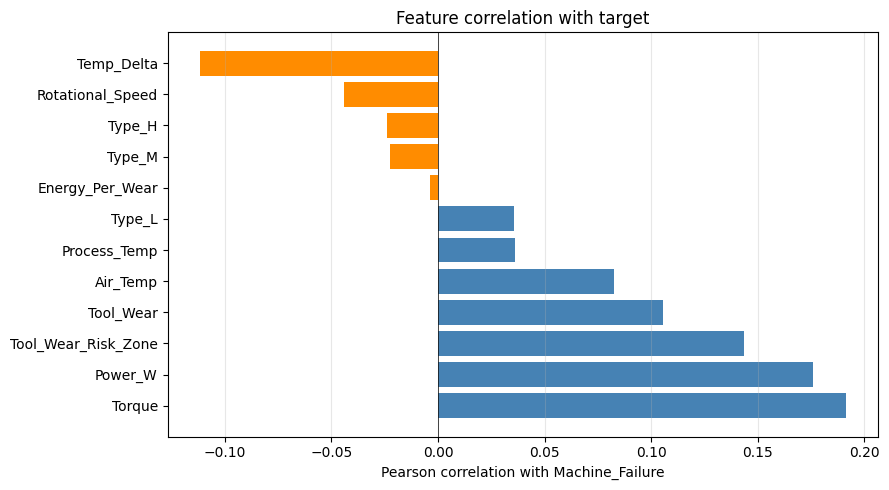

Top correlated features with Machine_Failure:
Torque                 0.191
Power_W                0.176
Tool_Wear_Risk_Zone    0.144
Tool_Wear              0.105
Air_Temp               0.083
Process_Temp           0.036
Type_L                 0.036
Energy_Per_Wear       -0.004
Name: Machine_Failure, dtype: float64


In [8]:
# Correlation with target
target_corr = df[feature_cols + ['Machine_Failure']].corr()['Machine_Failure'].drop('Machine_Failure').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['steelblue' if v > 0 else 'darkorange' for v in target_corr.values]
ax.barh(target_corr.index, target_corr.values, color=colors)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('Pearson correlation with Machine_Failure')
ax.set_title('Feature correlation with target')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('../figures/04_feature_correlation.png', dpi=120, bbox_inches='tight')
plt.show()

print('Top correlated features with Machine_Failure:')
print(target_corr.head(8).round(3))

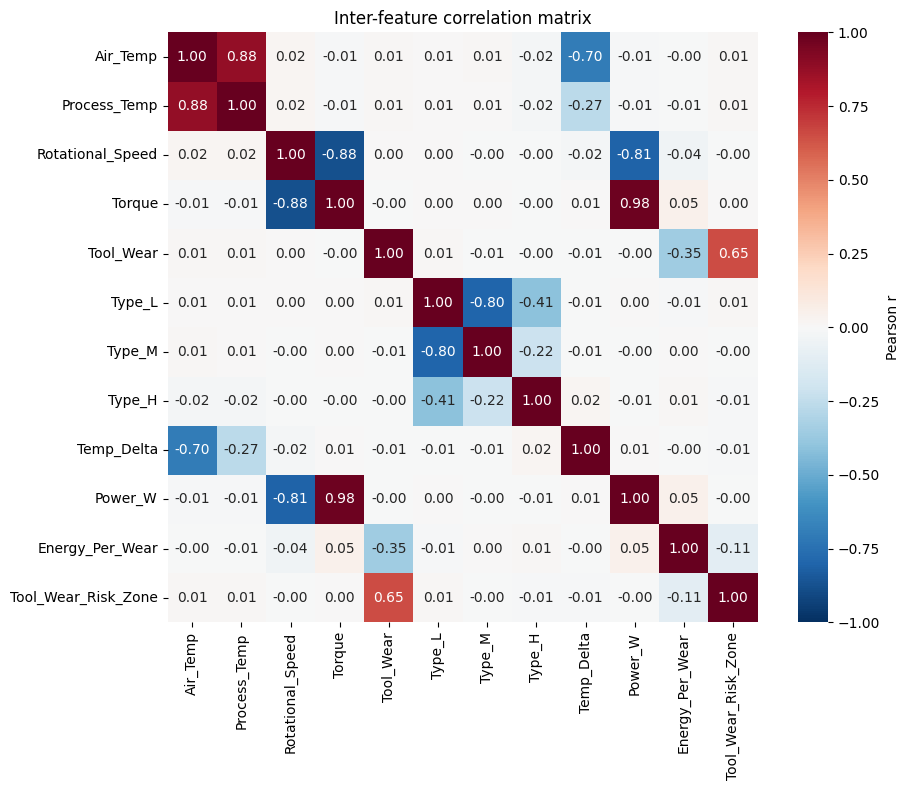

In [9]:
# Inter-feature correlation matrix (check for multicollinearity)
# We expect Power_W and Torque/RPM to correlate, but pure raw-pair correlation should be moderate
fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = df[feature_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, vmin=-1, vmax=1, ax=ax, cbar_kws={'label': 'Pearson r'})
ax.set_title('Inter-feature correlation matrix')
plt.tight_layout()
plt.savefig('../figures/05_feature_correlation_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

### What to look for in the correlation matrix

- **Power_W ↔ Torque** should correlate moderately. Power_W is the product of torque and RPM; some correlation is expected and harmless.
- **Power_W ↔ Rotational_Speed** should correlate moderately for the same reason.
- **Temp_Delta ↔ Process_Temp** should correlate strongly because Process_Temp dominates the gradient (Air_Temp varies little).
- **Energy_Per_Wear ↔ Power_W** should correlate at low Tool_Wear (when Tool_Wear is small, Energy_Per_Wear ≈ Power_W) but diverge as Tool_Wear increases.
- **One-hot Type columns** should be perfectly negatively correlated with each other by construction.
- **Tool_Wear_Risk_Zone ↔ Tool_Wear** will correlate strongly (the boolean is derived from the continuous), and that's OK — they encode different information (smooth vs threshold). Trees handle this without issue.

What we *don't* want to see: very high correlation (>0.95) between features that aren't supposed to be related, which would indicate a feature engineering bug.

## 7. Save Featured Dataset

In [10]:
# Keep all useful columns: identifiers, raw sensors, categorical (both versions for backward compat),
# engineered features, target, and failure type labels (for the OOD demo)
output_cols = [
    # Identifiers
    'ID', 'Product_ID', 'Product_Type',
    # Raw sensors
    'Air_Temp', 'Process_Temp', 'Rotational_Speed', 'Torque', 'Tool_Wear',
    # Categorical encoded
    'Type_L', 'Type_M', 'Type_H',
    # Engineered
    'Temp_Delta', 'Power_W', 'Energy_Per_Wear', 'Tool_Wear_Risk_Zone',
    # Target and failure types
    'Machine_Failure',
    'Tool_Wear_Failure', 'Heat_Dissipation_Failure', 'Power_Failure',
    'Overstrain_Failure', 'Random_Failure',
]

df[output_cols].to_csv('../data/processed/ai4i2020_featured.csv', index=False)
print(f'Saved {len(df)} rows × {len(output_cols)} columns to ../data/processed/ai4i2020_featured.csv')

Saved 10000 rows × 21 columns to ../data/processed/ai4i2020_featured.csv
